# Импорты, seed и устройство

In [38]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import torchvision
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import csv
import json

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

DATASET = "CIFAR10"
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
CSV_PATH = os.path.join(ARTIFACTS_DIR, "runs.csv")
if os.path.exists(CSV_PATH):
    os.remove(CSV_PATH)

BATCH_SIZE = 64
NUM_WORKERS = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.5.1+cpu


# Данные и DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # mean/std для 3 каналов
])

train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

val_size = int(len(train_full) * 0.2)
train_size = len(train_full) - val_size
print(f"val size: {val_size}, train_size: {train_size}")

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000
val size: 10000, train_size: 40000


In [40]:
gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

print("\nДиапазон значений для изображений")
print(f"min={x_batch.min().item():.3f}, max={x_batch.max().item():.3f}")

print("\nДиапазон значений для меток")
print(f"unique labels: {sorted(y_batch.unique().tolist())}")
print(f"min={y_batch.min().item()}, max={y_batch.max().item()}")
     

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64

Диапазон значений для изображений
min=-1.000, max=1.000

Диапазон значений для меток
unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
min=0, max=9


# Модель MLP и цикл обучения

In [41]:
class MLP(nn.Module):
    def __init__(self, dropout_p: float = 0.0, use_batchnorm: bool = False):
        super().__init__()
        act_layer = nn.ReLU

        layers = [nn.Flatten()]

        prev = 32*32*3
        for h in (256, 128):
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
print(model)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
logits: torch.Size([64, 10])


In [42]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [43]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [44]:
def plot_history(history: dict, title: str = "", save_path = None) -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if save_path != None: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# Эксперименты

## Часть A (S08): регуляризация и переобучение (обязательно)

In [45]:
def run_experiment(model_cfg, optimizer_cfg=None, epochs=20, earlyStopping = False):
    model = MLP(**model_cfg).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_cfg is None: optimizer_cfg = {'type': 'adam', 'lr': 1e-3}
    
    opt_type = optimizer_cfg['type']
    lr = optimizer_cfg['lr']
    if opt_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif opt_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), 
                              lr=lr,
                              momentum=optimizer_cfg['momentum'],
                              weight_decay=optimizer_cfg['weight_decay']
                              )
    else:
        raise ValueError(opt_type)

    print(f"Запуск обучения с оптимизатором {opt_type}, lr: {lr}")

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [],  'val_acc': []}
    early_stopping = EarlyStopping()
    
    best_val_loss = np.inf
    best_val_ac = 0 
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        if v_loss < best_val_loss and v_acc > best_val_ac:
            best_val_ac = v_acc
            best_val_loss = v_loss
        
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        
        print(f"Epoch {epoch+1:2d}. Train loss: {t_loss:.4f}, acc {t_acc:.4f} | Val loss: {v_loss:.4f}, acc {v_acc:.4f}")
        
        if earlyStopping and early_stopping.step(v_acc, model):
            print(f"Early stopping at epoch {epoch+1}")
            early_stopping.restore_best(model)
            break
    
    # Финальная оценка на val
    final_val_loss, final_val_acc = evaluate(model, val_loader, criterion, device)
    if v_loss < best_val_loss and v_acc > best_val_ac:
        best_val_ac = v_acc
        best_val_loss = v_loss
    print(f"final val loss: {final_val_loss}, final val acc: {final_val_acc:.4f}")
    
    return model, history, best_val_loss, best_val_ac

In [46]:
def save_experiment_result(filepath, **kwargs):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    
    fields = [
        'experiment_id', 'dataset', 'seed', 'model_summary',
        'optimizer', 'lr', 'momentum', 'weight_decay',
        'epochs_trained', 'best_val_accuracy', 'best_val_loss'
    ]
    
    file_exists = os.path.isfile(filepath)
    
    with open(filepath, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fields, extrasaction='ignore')
        if not file_exists:
            writer.writeheader()
        writer.writerow({field: kwargs.get(field, '') for field in fields})

In [47]:
# E1 (base) - без Dropout и без BatchNorm
dropout_p = 0.0
use_batchnorm = False
model_e1, hist_e1, val_loss_e1, val_acc_e1 = run_experiment(model_cfg={'dropout_p': dropout_p, 'use_batchnorm': use_batchnorm})
save_experiment_result(CSV_PATH,
    experiment_id="E1",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={dropout_p}, batchnorm = {use_batchnorm}",
    optimizer="Adam",
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    epochs_trained=len(hist_e1['train_loss']),
    best_val_accuracy=f"{val_acc_e1:.4f}",
    best_val_loss=f"{val_loss_e1:.4f}"
)
print(f"best E1 (base) val accuracy: {val_acc_e1:.4f}")

Запуск обучения с оптимизатором adam, lr: 0.001
Epoch  1. Train loss: 1.6620, acc 0.4084 | Val loss: 1.5285, acc 0.4583
Epoch  2. Train loss: 1.4516, acc 0.4874 | Val loss: 1.4559, acc 0.4908
Epoch  3. Train loss: 1.3440, acc 0.5239 | Val loss: 1.4054, acc 0.5060
Epoch  4. Train loss: 1.2578, acc 0.5543 | Val loss: 1.4064, acc 0.5085
Epoch  5. Train loss: 1.1820, acc 0.5824 | Val loss: 1.3900, acc 0.5183
Epoch  6. Train loss: 1.1079, acc 0.6053 | Val loss: 1.4028, acc 0.5196
Epoch  7. Train loss: 1.0383, acc 0.6316 | Val loss: 1.4209, acc 0.5249
Epoch  8. Train loss: 0.9750, acc 0.6512 | Val loss: 1.4407, acc 0.5196
Epoch  9. Train loss: 0.9067, acc 0.6760 | Val loss: 1.4904, acc 0.5286
Epoch 10. Train loss: 0.8462, acc 0.6986 | Val loss: 1.5204, acc 0.5283
Epoch 11. Train loss: 0.7932, acc 0.7156 | Val loss: 1.5569, acc 0.5243
Epoch 12. Train loss: 0.7345, acc 0.7369 | Val loss: 1.6495, acc 0.5265
Epoch 13. Train loss: 0.6913, acc 0.7540 | Val loss: 1.6792, acc 0.5201
Epoch 14. Train 

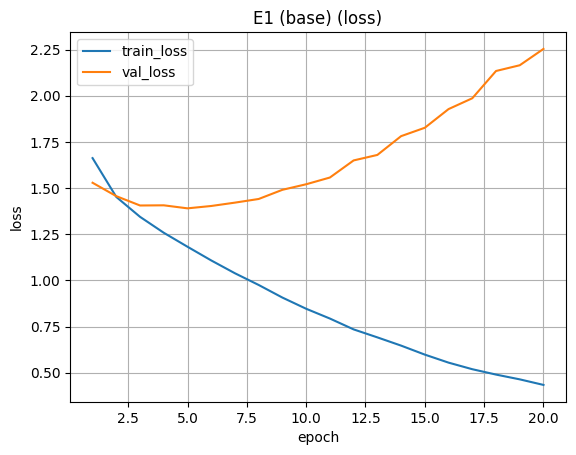

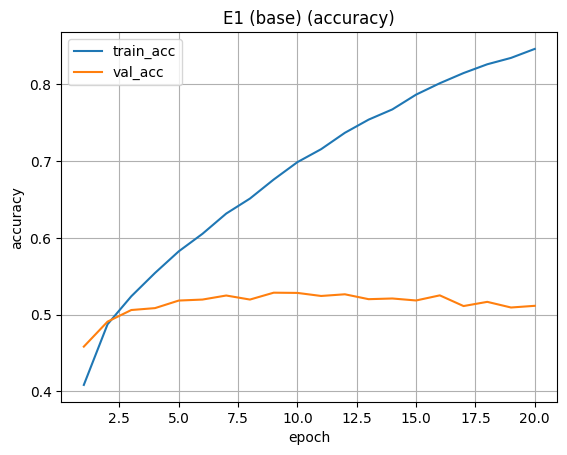

In [48]:
plot_history(hist_e1, title="E1 (base)")

In [49]:
# E2 (Dropout) - как E1, но добавить Dropout (например, p=0.2-0.5)
dropout_p = 0.3
use_batchnorm = False
model_e2, hist_e2, val_loss_e2, val_acc_e2 = run_experiment(model_cfg={'dropout_p': dropout_p, 'use_batchnorm': use_batchnorm})
save_experiment_result(CSV_PATH,
    experiment_id="E2",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={dropout_p}, batchnorm = {use_batchnorm}",
    optimizer="Adam",
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    epochs_trained=len(hist_e2['train_loss']),
    best_val_accuracy=f"{val_acc_e2:.4f}",
    best_val_loss=f"{val_loss_e2:.4f}"
)
print(f"best E2 (Dropout) val accuracy: {val_acc_e2:.4f}")

Запуск обучения с оптимизатором adam, lr: 0.001
Epoch  1. Train loss: 1.7955, acc 0.3600 | Val loss: 1.6109, acc 0.4333
Epoch  2. Train loss: 1.6420, acc 0.4147 | Val loss: 1.5320, acc 0.4613
Epoch  3. Train loss: 1.5752, acc 0.4441 | Val loss: 1.4945, acc 0.4740
Epoch  4. Train loss: 1.5306, acc 0.4567 | Val loss: 1.4558, acc 0.4876
Epoch  5. Train loss: 1.5011, acc 0.4693 | Val loss: 1.4347, acc 0.4874
Epoch  6. Train loss: 1.4655, acc 0.4819 | Val loss: 1.4209, acc 0.4885
Epoch  7. Train loss: 1.4386, acc 0.4906 | Val loss: 1.4048, acc 0.5103
Epoch  8. Train loss: 1.4071, acc 0.5019 | Val loss: 1.3818, acc 0.5128
Epoch  9. Train loss: 1.3943, acc 0.5087 | Val loss: 1.3871, acc 0.5117
Epoch 10. Train loss: 1.3671, acc 0.5147 | Val loss: 1.3744, acc 0.5175
Epoch 11. Train loss: 1.3420, acc 0.5215 | Val loss: 1.3783, acc 0.5195
Epoch 12. Train loss: 1.3253, acc 0.5254 | Val loss: 1.3590, acc 0.5197
Epoch 13. Train loss: 1.3045, acc 0.5342 | Val loss: 1.3906, acc 0.5122
Epoch 14. Train 

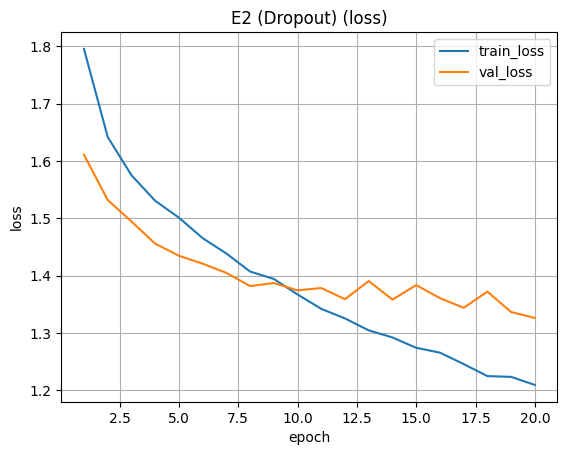

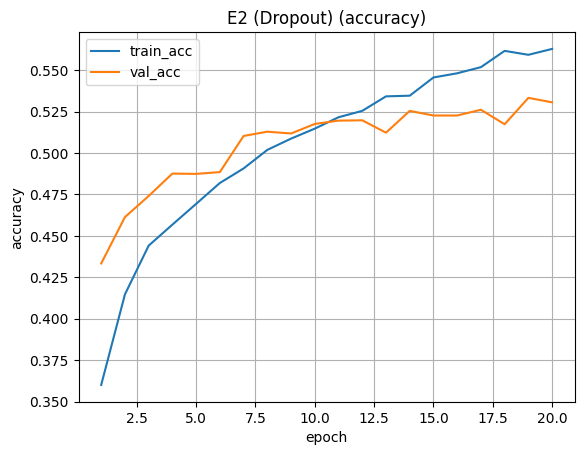

In [50]:
plot_history(hist_e2, title="E2 (Dropout)")

In [51]:
# E3 (BatchNorm) - как E1, но добавить BatchNorm (между Linear и активацией)
dropout_p = 0.0
use_batchnorm = True
model_e3, hist_e3, val_loss_e3, val_acc_e3 = run_experiment(model_cfg={'dropout_p': dropout_p, 'use_batchnorm': use_batchnorm})
save_experiment_result(CSV_PATH,
    experiment_id="E3",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={dropout_p}, batchnorm = {use_batchnorm}",
    optimizer="Adam",
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    epochs_trained=len(hist_e3['train_loss']),
    best_val_accuracy=f"{val_acc_e3:.4f}",
    best_val_loss=f"{val_loss_e3:.4f}"
)

print(f"best E3 (BatchNorm) val accuracy: {val_acc_e3:.4f}")

Запуск обучения с оптимизатором adam, lr: 0.001
Epoch  1. Train loss: 1.6455, acc 0.4102 | Val loss: 1.4920, acc 0.4722
Epoch  2. Train loss: 1.4270, acc 0.4932 | Val loss: 1.3844, acc 0.5061
Epoch  3. Train loss: 1.3233, acc 0.5278 | Val loss: 1.3613, acc 0.5191
Epoch  4. Train loss: 1.2480, acc 0.5543 | Val loss: 1.3184, acc 0.5264
Epoch  5. Train loss: 1.1791, acc 0.5779 | Val loss: 1.3079, acc 0.5378
Epoch  6. Train loss: 1.1226, acc 0.6006 | Val loss: 1.3155, acc 0.5429
Epoch  7. Train loss: 1.0609, acc 0.6243 | Val loss: 1.3087, acc 0.5465
Epoch  8. Train loss: 1.0196, acc 0.6378 | Val loss: 1.3161, acc 0.5448
Epoch  9. Train loss: 0.9686, acc 0.6545 | Val loss: 1.3424, acc 0.5395
Epoch 10. Train loss: 0.9147, acc 0.6770 | Val loss: 1.3605, acc 0.5457
Epoch 11. Train loss: 0.8680, acc 0.6925 | Val loss: 1.3590, acc 0.5470
Epoch 12. Train loss: 0.8216, acc 0.7080 | Val loss: 1.3865, acc 0.5474
Epoch 13. Train loss: 0.7812, acc 0.7237 | Val loss: 1.4006, acc 0.5450
Epoch 14. Train 

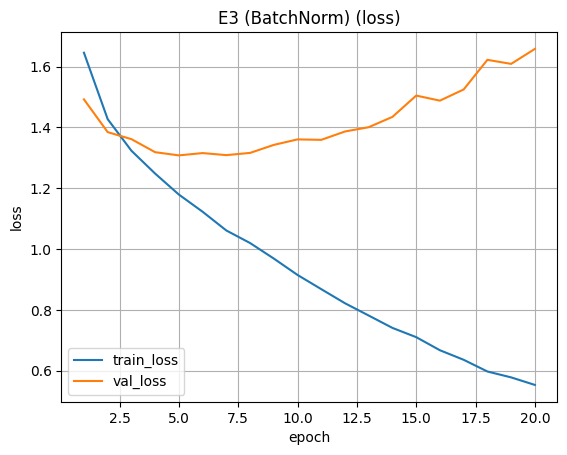

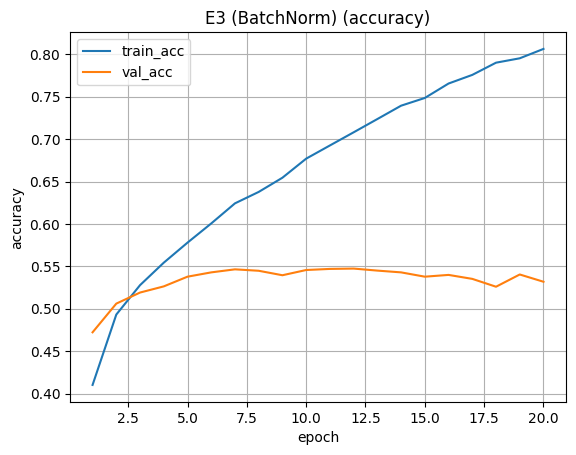

In [52]:
plot_history(hist_e3, title="E3 (BatchNorm)")

### **E4 (EarlyStopping)**: выбрать **лучший** из (E2/E3) по `val_accuracy` и обучить его с EarlyStopping (patience 3-5).
  - именно E4 считается "лучшей моделью домашки" и из него сохраняется `best_model.pt`

In [53]:
best_model_cfg={'dropout_p': 0, 'use_batchnorm': True} # E2
model_e4, hist_e4, val_loss_e4, val_acc_e4 = run_experiment(model_cfg=best_model_cfg, earlyStopping=True)
save_experiment_result(CSV_PATH,
    experiment_id="E4",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={best_model_cfg['dropout_p']}, batchnorm = {best_model_cfg['use_batchnorm']}",
    optimizer="Adam",
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    epochs_trained=len(hist_e4['train_loss']),
    best_val_accuracy=f"{val_acc_e4:.4f}",
    best_val_loss=f"{val_loss_e4:.4f}"
)

test_loss_e4, test_acc_e4 = evaluate(model_e4, test_loader, criterion, device)
print(f"E4 test: loss={test_loss_e4:.4f}, acc={test_acc_e4:.4f}")

torch.save(model_e4.state_dict(), os.path.join(ARTIFACTS_DIR, "best_model.pt"))
model_conf = model_e4
best_config = {
    "experiment_id": "E4",
    "dataset": "KMNIST",
    "seed": 42,
    "model": {
        "architecture": "MLP",
        "input_size": 3*32*32,
        "hidden_layers": [256, 128],
        "activation": "ReLU",
        "dropout_p": best_model_cfg['dropout_p'],
        "use_batchnorm": best_model_cfg['use_batchnorm'],
        "num_classes": 10
    },
    "optimizer": {
        "type": "Adam",
        "lr": 1e-3,
    },
    "training": {
        "criterion": "CrossEntropyLoss",
        "batch_size": 64,
        "max_epochs": 30,
        "early_stopping": True
    },
    "results": {
        "best_test_accuracy": float(test_acc_e4),
        "best_test_loss": test_loss_e4,
        "epochs_trained": len(hist_e4['train_loss'])
    }
}
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

Запуск обучения с оптимизатором adam, lr: 0.001
Epoch  1. Train loss: 1.6371, acc 0.4139 | Val loss: 1.4695, acc 0.4734
Epoch  2. Train loss: 1.4240, acc 0.4927 | Val loss: 1.3757, acc 0.5107
Epoch  3. Train loss: 1.3228, acc 0.5284 | Val loss: 1.3361, acc 0.5270
Epoch  4. Train loss: 1.2474, acc 0.5557 | Val loss: 1.3307, acc 0.5308
Epoch  5. Train loss: 1.1844, acc 0.5757 | Val loss: 1.3242, acc 0.5326
Epoch  6. Train loss: 1.1254, acc 0.5998 | Val loss: 1.3195, acc 0.5422
Epoch  7. Train loss: 1.0707, acc 0.6199 | Val loss: 1.3145, acc 0.5405
Epoch  8. Train loss: 1.0185, acc 0.6371 | Val loss: 1.3652, acc 0.5284
Epoch  9. Train loss: 0.9725, acc 0.6525 | Val loss: 1.3247, acc 0.5440
Epoch 10. Train loss: 0.9200, acc 0.6748 | Val loss: 1.3794, acc 0.5299
Epoch 11. Train loss: 0.8745, acc 0.6897 | Val loss: 1.4195, acc 0.5308
Epoch 12. Train loss: 0.8299, acc 0.7052 | Val loss: 1.3902, acc 0.5473
Epoch 13. Train loss: 0.7884, acc 0.7224 | Val loss: 1.4184, acc 0.5465
Epoch 14. Train 

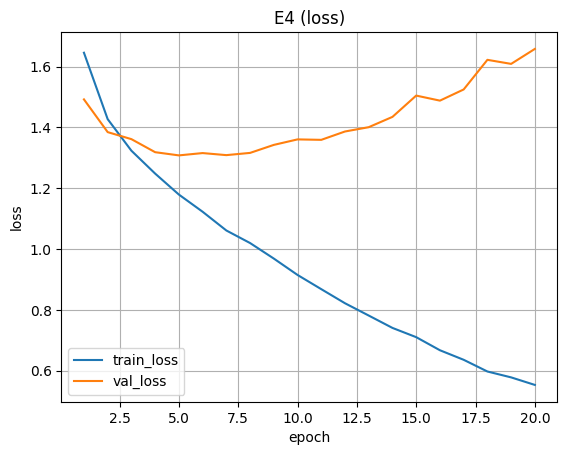

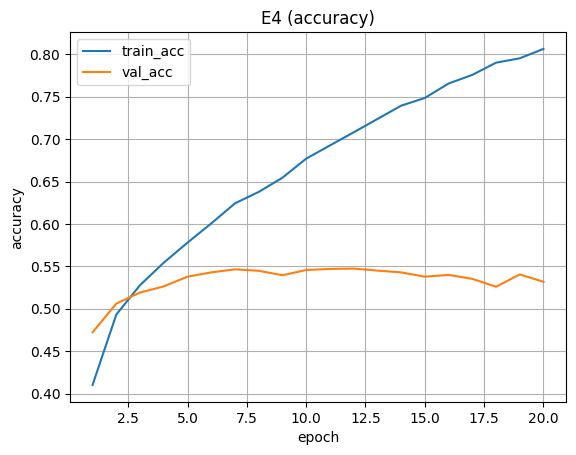

In [54]:
plot_history(hist_e3, title="E4", save_path=os.path.join(FIGURES_DIR, "curves_best.png"))

## Часть B (S09): LR, оптимизаторы, weight decay (обязательно)

In [56]:
# O1: Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо
optimizer_cfg={'type': 'adam', 'lr': 1e-1}
model_O1, hist_O1, val_loss_O1, val_acc_O1 = run_experiment(model_cfg=best_model_cfg, optimizer_cfg=optimizer_cfg, epochs=8)
save_experiment_result(CSV_PATH,
    experiment_id="O1",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={best_model_cfg['dropout_p']}, batchnorm = {best_model_cfg['use_batchnorm']}",
    optimizer=optimizer_cfg['type'],
    lr=optimizer_cfg['lr'],
    momentum=0,
    weight_decay=0,
    epochs_trained=len(hist_O1['train_loss']),
    best_val_accuracy=f"{val_acc_O1:.4f}",
    best_val_loss=f"{val_loss_O1:.4f}"
)

Запуск обучения с оптимизатором adam, lr: 0.1
Epoch  1. Train loss: 1.8645, acc 0.3248 | Val loss: 1.6998, acc 0.3684
Epoch  2. Train loss: 1.6786, acc 0.3934 | Val loss: 1.5879, acc 0.4345
Epoch  3. Train loss: 1.5972, acc 0.4213 | Val loss: 1.5849, acc 0.4273
Epoch  4. Train loss: 1.5535, acc 0.4398 | Val loss: 1.5417, acc 0.4378
Epoch  5. Train loss: 1.5092, acc 0.4589 | Val loss: 1.5439, acc 0.4455
Epoch  6. Train loss: 1.4907, acc 0.4668 | Val loss: 1.5549, acc 0.4326
Epoch  7. Train loss: 1.4551, acc 0.4780 | Val loss: 1.4763, acc 0.4714
Epoch  8. Train loss: 1.4278, acc 0.4878 | Val loss: 1.4539, acc 0.4787
final val loss: 1.4538586819247834, final val acc: 0.4787


In [57]:
# O2: Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается
optimizer_cfg={'type': 'adam', 'lr': 1e-6}
model_02, hist_O2, val_loss_O2, val_acc_O2 = run_experiment(model_cfg=best_model_cfg, optimizer_cfg=optimizer_cfg, epochs=8)
save_experiment_result(CSV_PATH,
    experiment_id="O2",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={best_model_cfg['dropout_p']}, batchnorm = {best_model_cfg['use_batchnorm']}",
    optimizer=optimizer_cfg['type'],
    lr=optimizer_cfg['lr'],
    momentum=0,
    weight_decay=0,
    epochs_trained=len(hist_O2['train_loss']),
    best_val_accuracy=f"{val_acc_O2:.4f}",
    best_val_loss=f"{val_loss_O2:.4f}"
)

Запуск обучения с оптимизатором adam, lr: 1e-06
Epoch  1. Train loss: 2.2232, acc 0.1878 | Val loss: 2.1393, acc 0.2429
Epoch  2. Train loss: 2.0935, acc 0.2636 | Val loss: 2.0520, acc 0.2945
Epoch  3. Train loss: 2.0234, acc 0.3003 | Val loss: 1.9985, acc 0.3175
Epoch  4. Train loss: 1.9753, acc 0.3242 | Val loss: 1.9545, acc 0.3387
Epoch  5. Train loss: 1.9392, acc 0.3407 | Val loss: 1.9232, acc 0.3490
Epoch  6. Train loss: 1.9103, acc 0.3532 | Val loss: 1.8986, acc 0.3604
Epoch  7. Train loss: 1.8850, acc 0.3630 | Val loss: 1.8731, acc 0.3716
Epoch  8. Train loss: 1.8637, acc 0.3690 | Val loss: 1.8599, acc 0.3764
final val loss: 1.8599196733183163, final val acc: 0.3764


In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))    
# O1 и O2 эпохи
epochs_o1 = range(1, len(hist_O1['train_loss']) + 1)
epochs_o2 = range(1, len(hist_O2['train_loss']) + 1)

axes[0, 0].semilogy(epochs_o1, hist_O1['train_loss'], label='O1 Train', color='red')
axes[0, 0].semilogy(epochs_o1, hist_O1['val_loss'], label='O1 Val', color='red')
axes[0, 0].set_title('O1: LR слишком большой (1e-1)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].semilogy(epochs_o2, hist_O2['train_loss'], label='O2 Train', color='orange')
axes[0, 1].semilogy(epochs_o2, hist_O2['val_loss'], label='O2 Val', color='orange')
axes[0, 1].set_title('O2: LR слишком маленький (1e-5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss (log)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_o1, hist_O1['train_acc'], label='O1 Train', color='red')
axes[1, 0].plot(epochs_o1, hist_O1['val_acc'], label='O1 Val', color='red')
axes[1, 0].set_title('O1: Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_o2, hist_O2['train_acc'], label='O2 Train', color='orange')
axes[1, 1].plot(epochs_o2, hist_O2['val_acc'], label='O2 Val', color='orange')
axes[1, 1].set_title('O2: Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)


plt.suptitle('Сравнение экстремальных learning rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"), dpi=150, bbox_inches='tight')
plt.close()

In [59]:
# O3 (SGD+momentum + weight decay): SGD с momentum (например, momentum=0.9) и **weight_decay > 0** (например, 1e-4)
# lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3)
# обучить 10-15 эпох (или меньше, если на CPU долго)
optimizer_cfg={'type': 'sgd', 'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-4}
model_O3, hist_O3, val_loss_O3, val_acc_O3 = run_experiment(model_cfg=best_model_cfg, optimizer_cfg=optimizer_cfg, epochs=10)
test_loss_O3, test_acc_O3 = evaluate(model_O3, test_loader, criterion, device)
print(f"O3 (base) test: loss={test_loss_O3:.4f}, acc={test_acc_O3:.4f}")
save_experiment_result(CSV_PATH,
    experiment_id="O3",
    dataset=DATASET,
    seed=SEED,
    model_summary=f"hidden sizes (256,128), activation ReLU, dropout_p={best_model_cfg['dropout_p']}, batchnorm = {best_model_cfg['use_batchnorm']}",
    optimizer=optimizer_cfg['type'],
    lr=optimizer_cfg['lr'],
    momentum=optimizer_cfg['momentum'],
    weight_decay=optimizer_cfg['weight_decay'],
    epochs_trained=len(hist_O3['train_loss']),
    best_val_accuracy=f"{val_acc_O3:.4f}",
    best_val_loss=f"{val_loss_O3:.4f}"
)

Запуск обучения с оптимизатором sgd, lr: 0.001
Epoch  1. Train loss: 1.7309, acc 0.3935 | Val loss: 1.5774, acc 0.4471
Epoch  2. Train loss: 1.5028, acc 0.4733 | Val loss: 1.4775, acc 0.4775
Epoch  3. Train loss: 1.3976, acc 0.5076 | Val loss: 1.4175, acc 0.5007
Epoch  4. Train loss: 1.3223, acc 0.5341 | Val loss: 1.3881, acc 0.5110
Epoch  5. Train loss: 1.2586, acc 0.5573 | Val loss: 1.3666, acc 0.5234
Epoch  6. Train loss: 1.2044, acc 0.5744 | Val loss: 1.3457, acc 0.5243
Epoch  7. Train loss: 1.1581, acc 0.5912 | Val loss: 1.3371, acc 0.5294
Epoch  8. Train loss: 1.1088, acc 0.6131 | Val loss: 1.3390, acc 0.5257
Epoch  9. Train loss: 1.0647, acc 0.6256 | Val loss: 1.3479, acc 0.5248
Epoch 10. Train loss: 1.0318, acc 0.6397 | Val loss: 1.3504, acc 0.5279
final val loss: 1.3504192373555177, final val acc: 0.5279
O3 (base) test: loss=1.3527, acc=0.5241


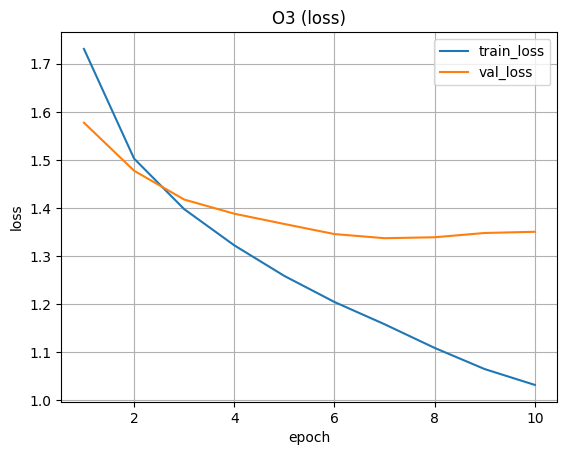

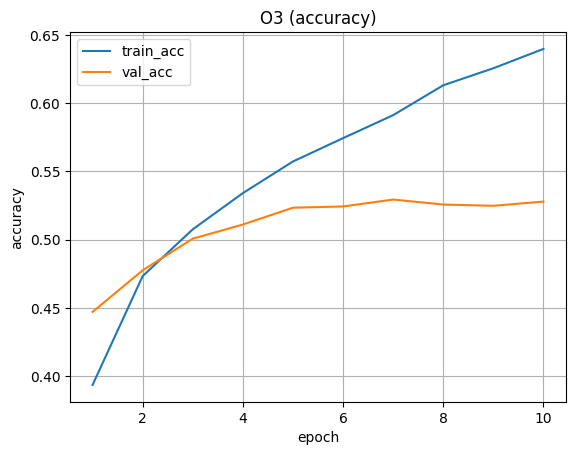

In [60]:
plot_history(hist_O3, title="O3")